<a href="https://colab.research.google.com/github/JakeEisner/ECON3916-Statistical-Machine-Learning/blob/main/Assignment%203/Econ_3916_Assignment_3_Causal_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The Mission: You have been recruited as a Senior Data Economist at SwiftCart Logistics , a multinational on-demand delivery platform. The executive board is currently paralyzed by contradictory data regarding driver compensation equity, the efficacy of a new batch-routing algorithm, and the true Return on Investment (ROI) of the "SwiftPass" premium subscription service.

Your mandate is to cut through the statistical noise. You will discard the fragile parametric assumptions that fail in real-world logistics, relying instead on heavy computation to build empirical evidence and isolate pure causality from spurious correlation.

In [72]:
# Enviornment Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

In [73]:
# Phase 1: Bootstrapping Non-Parametric Uncertainty

# Step 1.1: The Zero-Inflated Gig Economy Tip Distribution
np.random.seed(42)
zeros = np.zeros(100)
tips = np.random.exponential(scale=5.0, size=150)
driver_tips = np.concatenate([zeros, tips])

In [74]:
# Step 1.2: The Manual Bootstrap Engine
bootstrap_medians = []
for i in range(10000):
  sample = np.random.choice(driver_tips, size = len(driver_tips), replace = True)
  median = np.median(sample)
  bootstrap_medians.append(median)

bootstrap_medians = np.array(bootstrap_medians)

ci_lower = np.percentile(bootstrap_medians, 2.5)
ci_upper = np.percentile(bootstrap_medians, 97.5)

print("95% Confidence Interval for Median:")
print("Lower:", ci_lower)
print("Upper:", ci_upper)

95% Confidence Interval for Median:
Lower: 0.2653018357387816
Upper: 1.3635639228066991


In [75]:
# Step 2.1: The Algorithmic Routing Crash
np.random.seed(42)

control = np.random.normal(loc = 35, scale = 5, size = 500)
treatment = np.random.lognormal(mean = 3.4, sigma = 0.4, size = 500)
observed_difference = np.mean(control) - np.mean(treatment)

print("Control mean:", np.mean(control))
print("Treatment mean:", np.mean(treatment))
print("Observed difference:", observed_difference)

Control mean: 35.03418997294323
Treatment mean: 32.76920784231749
Observed difference: 2.2649821306257394


In [76]:
# Step 2.2: The Exact Non-Parametric Permutation

deliveries = np.concatenate([control, treatment])
perm_diffs = []
for i in range(5000):
  shuffled = np.random.permutation(deliveries)
  pseudo_control = shuffled[:500]
  pseudo_treatment = shuffled[500:]
  diff = np.mean(pseudo_control) - np.mean(pseudo_treatment)
  perm_diffs.append(diff)

perm_diffs = np.array(perm_diffs)

p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_difference))

print("Empirical P-value", p_value)


Empirical P-value 0.0004


In [77]:
# Phase 3: Casual Control and the Mitigation of Selection Bias

# Step 3.1: The Loyalty Program Paradox
df = pd.read_csv("swiftcart_loyalty.csv")
df.head()
df.columns

treated_mean = df[df["subscriber"] == 1]["post_spend"].mean()
control_mean = df[df["subscriber"] == 0]["post_spend"].mean()

naive_sdo = treated_mean - control_mean

print("Subscriber mean spending:", treated_mean)
print("Non-subscriber mean spending", control_mean)
print("Naive SDO:", naive_sdo)

Subscriber mean spending: 74.04358604052543
Non-subscriber mean spending 56.47291665600164
Naive SDO: 17.57066938452379


In [78]:
X = df[["pre_spend", "account_age", "support_tickets"]]
y = df["subscriber"]

model = LogisticRegression()
model.fit(X, y)

df["propensity_score"] = model.predict_proba(X)[:, 1]

df.head()

,subscriber,pre_spend,account_age,support_tickets,post_spend,propensity_score
0,1,57.450712,37,2,85.169648,0.546500
1,1,47.926035,41,0,72.802404,0.548460
2,1,59.715328,41,0,79.858905,0.683988
3,1,72.845448,34,0,80.335466,0.779637
4,1,46.487699,34,2,67.956227,0.397513


In [79]:
treated = df[df["subscriber"] == 1]
control = df[df["subscriber"] == 0]
nn = NearestNeighbors(n_neighbors = 1)
nn.fit(control[["propensity_score"]])
distances, indices = nn.kneighbors(treated[["propensity_score"]])
matched_control = control.iloc[indices.flatten()]

In [80]:
att = np.mean(
    treated["post_spend"].values - matched_control["post_spend"].values
)

print("Naive SDO:", naive_sdo)
print("ATT after matching:", att)

Naive SDO: 17.57066938452379
ATT after matching: 9.913855182824864


The naive difference in means suggests that SwiftPass subscribers spend 17.57 more each month than non-subscribers. It is important to note that this esitmate is baised becuase the higher-spending users are more likely to self-select themselves into the loyalty program. In order to correct for this selection bias, I estimated propensity scores using logistic regression based on the pre-treatment characteristics: prior spending, account age, and support tickets. Then, each subscribers were matched with the most similar non-subscriber using nearest neighbor matching. Lastly, after I matched the comparable users, the ATT on Treated was $9.91. This shows us that the naive estimate overstated the true causal effect of SwiftPass. A lot of the observed difference in spending was explained by self-selection and not the program itself.

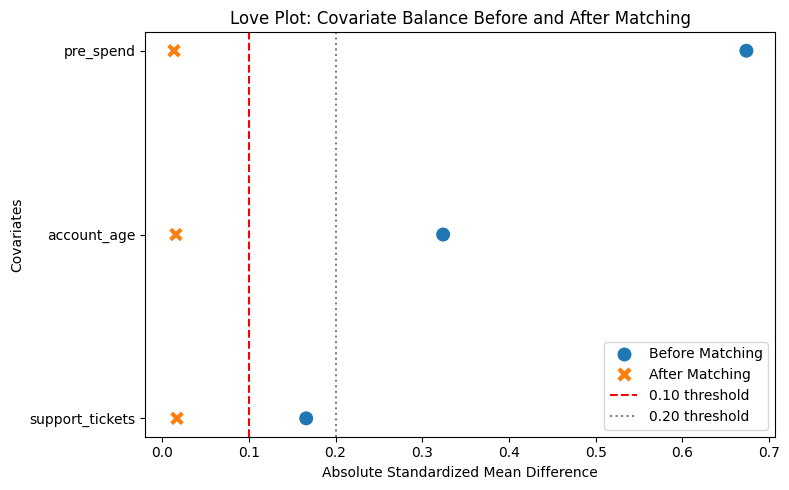

,Covariate,Before Matching,After Matching
0,pre_spend,0.673959,0.013664
1,account_age,0.324109,0.015871
2,support_tickets,0.166146,0.017112


In [81]:
# -------------------------------
# Task 4.1: Love Plot Visualization
# -------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# Create datasets
# -------------------------------

# original dataset
df_unmatched = df.copy()

# matched dataset (treated + matched controls)
df_matched = pd.concat([treated, matched_control], axis=0)

# -------------------------------
# covariates used in matching
# -------------------------------

covariates = ["pre_spend", "account_age", "support_tickets"]
treatment_col = "subscriber"

# -------------------------------
# function to compute SMD
# -------------------------------

def compute_smd(df, covariate):

    treated_vals = df[df[treatment_col] == 1][covariate]
    control_vals = df[df[treatment_col] == 0][covariate]

    mean_t = treated_vals.mean()
    mean_c = control_vals.mean()

    var_t = treated_vals.var()
    var_c = control_vals.var()

    pooled_sd = np.sqrt((var_t + var_c) / 2)

    smd = (mean_t - mean_c) / pooled_sd

    return abs(smd)

# -------------------------------
# compute SMDs
# -------------------------------

smd_before = [compute_smd(df_unmatched, c) for c in covariates]
smd_after = [compute_smd(df_matched, c) for c in covariates]

love_df = pd.DataFrame({
    "Covariate": covariates,
    "Before Matching": smd_before,
    "After Matching": smd_after
})

# reshape for plotting
love_long = love_df.melt(
    id_vars="Covariate",
    value_vars=["Before Matching", "After Matching"],
    var_name="Stage",
    value_name="Absolute SMD"
)

# -------------------------------
# Love Plot
# -------------------------------

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=love_long,
    x="Absolute SMD",
    y="Covariate",
    hue="Stage",
    style="Stage",
    s=120
)

plt.axvline(0.10, linestyle="--", color="red", label="0.10 threshold")
plt.axvline(0.20, linestyle=":", color="gray", label="0.20 threshold")

plt.title("Love Plot: Covariate Balance Before and After Matching")
plt.xlabel("Absolute Standardized Mean Difference")
plt.ylabel("Covariates")

plt.legend()
plt.tight_layout()
plt.show()

# display numeric results
display(love_df)

AI evaluation: The Love Plot shows the standardized mean differences for the pre-treatment covariates before and after matching. Prior to matching, the treated and control groups exhibit meaningful imbalance, particularly for pre_spend and account_age. After applying propensity score matching, the standardized mean differences for all covariates fall well below the commonly accepted 0.10 threshold, indicating strong covariate balance. The substantial reduction in imbalance across all features suggests that the matching procedure successfully mitigated observable selection bias. While balance in observed covariates cannot guarantee that unobserved confounding has been eliminated, the Love Plot provides strong visual evidence that the treatment and control groups are now comparable along the measured dimensions.